In [17]:
# Reconstruction analysis

import numpy as np
import matplotlib.pyplot as plt
import os

img_path = f'/home/kale-chen/Documents/CASToR/images/'
name = 'hcenterfinal'
namen = 'hcenterfinaln'
dim = (10, 10, 50)
vox = (2, 2, 2)

(8, 8, 48) (8, 8, 48)
None 0.003944515 0.004741173


(0.78, 1.22)

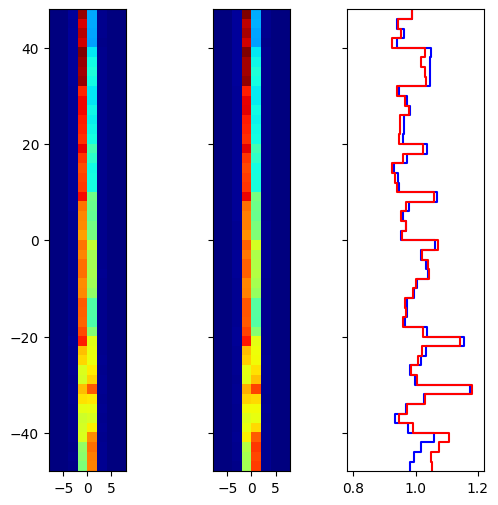

In [18]:
trim = (1, 1, 1)
img = np.fromfile(os.path.join(img_path, name, f'{name}_it1.img'), dtype = np.float32).reshape(dim, order = 'F')
img = np.flip(img, axis=1)
img = np.flip(img, axis=2)
imgn = np.fromfile(os.path.join(img_path, namen, f'{namen}_it1.img'), dtype = np.float32).reshape(dim, order = 'F')
imgn = np.flip(imgn, axis=1)
imgn = np.flip(imgn, axis=2)
img = img[trim[0]:-trim[0], trim[1]:-trim[1], trim[2]:-trim[2]]
imgn = imgn[trim[0]:-trim[0], trim[1]:-trim[1], trim[2]:-trim[2]]
print(print(img.shape, imgn.shape), np.mean(img), np.mean(imgn))
collapsex = img.sum(axis = 0)
collapsexn = imgn.sum(axis = 0)
slices, slicesn = [], []
imgmean = img.sum() / (img.shape[2])
imgnmean = imgn.sum() / (imgn.shape[2])
for i in range(img.shape[2]):
    slices.append(img[:, :, i].sum() / imgmean)
    slicesn.append(imgn[:, :, i].sum() / imgnmean)
slices.insert(0, slices[0])
slicesn.insert(0, slicesn[0])
fig, ax = plt.subplots(1, 3, figsize = (6, 6), width_ratios = [1, 1, 1], height_ratios = [1], sharey=True)
extenty = (-img.shape[1] * vox[1] / 2, img.shape[1] * vox[1] / 2)
extentz = (-img.shape[2] * vox[2] / 2, img.shape[2] * vox[2] / 2)
ax[0].imshow(collapsex.T, cmap = 'jet', extent = [extenty[0], extenty[1], extentz[0], extentz[1]])
ax[1].imshow(collapsexn.T, cmap = 'jet', extent = [extenty[0], extenty[1], extentz[0], extentz[1]])
ax[2].step(slices, np.linspace(extentz[1], extentz[0], img.shape[2] + 1), where = 'post', color = 'blue', label = 'un')
ax[2].step(slicesn, np.linspace(extentz[1], extentz[0], img.shape[2] + 1), where = 'post', color = 'red', label = 'norm')
#x[2].set_xlim(0.5, 1.5)
ax[2].set_xlim(0.78, 1.22)